In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("OnlineRetail.csv",  encoding="latin1")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df = df.drop_duplicates()
df = df.dropna()
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


In [7]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
print("Total Revenue:", df["Revenue"].sum())


Total Revenue: 8887208.894000001


In [9]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
print(top_products.head)

<bound method NDFrame.head of Description
PAPER CRAFT , LITTLE BIRDIE           168469.600
REGENCY CAKESTAND 3 TIER              142264.750
WHITE HANGING HEART T-LIGHT HOLDER    100392.100
JUMBO BAG RED RETROSPOT                85040.540
MEDIUM CERAMIC TOP STORAGE JAR         81416.730
                                         ...    
PURPLE FRANGIPANI HAIRCLIP                 0.850
VINTAGE BLUE TINSEL REEL                   0.840
SET 12 COLOURING PENCILS DOILEY            0.650
HEN HOUSE W CHICK IN NEST                  0.420
PADS TO MATCH ALL CUSHIONS                 0.003
Name: Revenue, Length: 3877, dtype: float64>


In [10]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
print(country_revenue.head)

<bound method NDFrame.head of Country
United Kingdom          7285024.644
Netherlands              285446.340
EIRE                     265262.460
Germany                  228678.400
France                   208934.310
Australia                138453.810
Spain                     61558.560
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38367.830
Japan                     37416.370
Norway                    36165.440
Portugal                  33375.840
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20440.540
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13502.850
Austria                   10198.680
Poland                     7334.650
Israel                     7215.840
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                     

In [11]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue = (
    df.groupby("Month")["Revenue"]
    .sum()
    .sort_index()
)
print(monthly_revenue.head)

<bound method NDFrame.head of Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64>


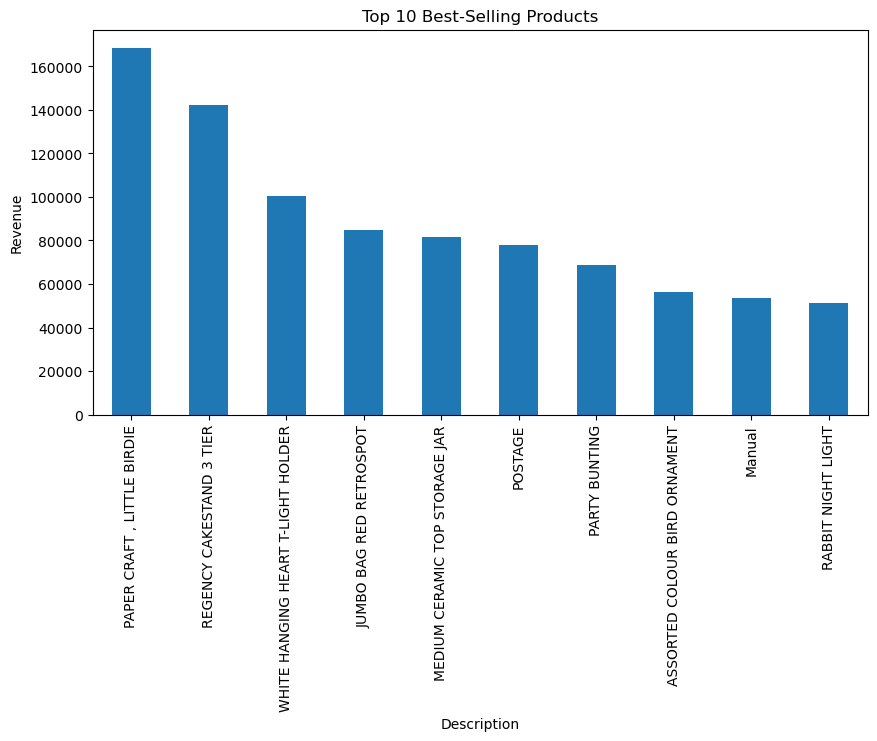

In [13]:
top_products.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Best-Selling Products")
plt.ylabel("Revenue")
plt.show()


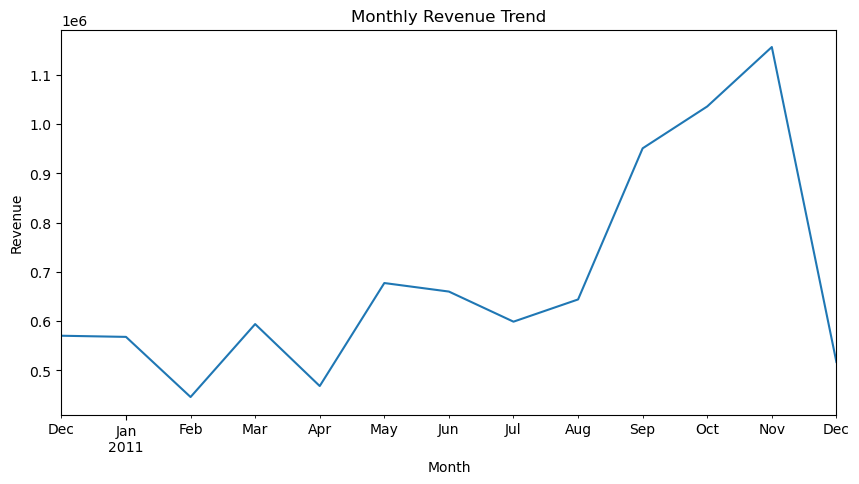

In [14]:
monthly_revenue.plot(kind="line", figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.show()


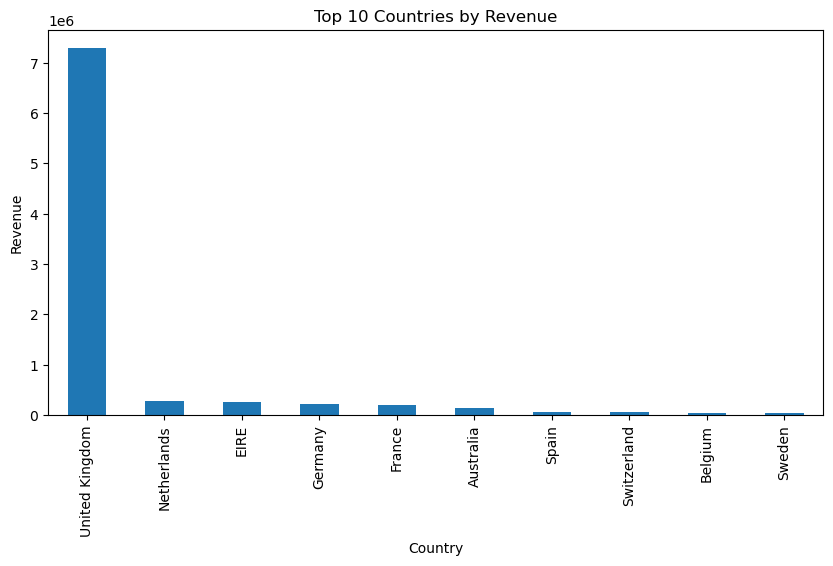

In [15]:
country_revenue.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.show()


In [18]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
top_product = top_products.idxmax()
top_country = country_revenue.idxmax()

monthly_growth = monthly_revenue.pct_change() * 100

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Top Product:", top_product)
print("Top Country:", top_country)


Total Revenue: 8887208.894000001
Total Orders: 18532
Top Product: PAPER CRAFT , LITTLE BIRDIE
Top Country: United Kingdom
